# Lecture-2 Linear Model

In [51]:
from data_loader import Data
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

data = Data(size=600)

(samples, targets) = next(iter(data.dataloader))

print(samples.shape)
print(targets.shape)



torch.Size([16, 1, 32, 32])
torch.Size([16])


## Let's define our very first linear Model

In [52]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.fc1 = nn.Linear(32*32*1, 10)

    def forward(self, x):
        x = self.fc1(x)
        return x


In [53]:
# Lets look at what our model is about
model = Model()

print(model)


Model(
  (fc1): Linear(in_features=1024, out_features=10, bias=True)
)


## Linear Model Comes with Weight Matrix and Bias Vector

In [54]:
print(model.fc1.weight.shape)
print(model.fc1.bias.shape)


torch.Size([10, 1024])
torch.Size([10])


## Lets to a forward run with this baby model, which doesn't know anything yet

In [55]:
samples = samples.view(samples.shape[0], -1)
output = model(samples)
print(output.shape)

torch.Size([16, 10])


In [56]:
print(output[0])
# These are the logits, i.e. our z_k, for k=1..10

tensor([-0.3019, -0.4109, -0.3743,  0.2038, -0.2242, -0.1315,  0.1967, -0.0439,
        -1.2805, -0.3027], grad_fn=<SelectBackward0>)


## Now Let's define our Softmax function

In [57]:
def softmax(z):
    return torch.exp(z) / torch.sum(torch.exp(z), dim=1, keepdim=True)


In [58]:
probs = softmax(output)
print(probs[0])


tensor([0.0904, 0.0810, 0.0840, 0.1498, 0.0977, 0.1071, 0.1488, 0.1169, 0.0340,
        0.0903], grad_fn=<SelectBackward0>)


## But hey, of course torch comes with softmax - but it was good to know that we could design our own activation functions

In [59]:
softmax2 = nn.Softmax(dim=1)

probs2 = softmax2(output)
print(probs[0])
print(probs2[0])

tensor([0.0904, 0.0810, 0.0840, 0.1498, 0.0977, 0.1071, 0.1488, 0.1169, 0.0340,
        0.0903], grad_fn=<SelectBackward0>)
tensor([0.0904, 0.0810, 0.0840, 0.1498, 0.0977, 0.1071, 0.1488, 0.1169, 0.0340,
        0.0903], grad_fn=<SelectBackward0>)


## Now let's define the Cross Entropy

In [60]:
def cross_entropy(output, target):
    return -torch.sum(target * torch.log(output))

labels = F.one_hot(targets, num_classes=10)
print(cross_entropy(probs, labels))

tensor(40.0061, grad_fn=<NegBackward0>)


## Now we have seen a sample, we have seen it's labels - let's teach our model to learn from this. Are you ready? Drum rolls

In [61]:
hand_calculated_grad_weight = (softmax(model(samples)) - F.one_hot(targets, num_classes=10)).T @ samples.view(samples.shape[0], -1)
hand_calculated_grad_bias = (softmax(model(samples)) - F.one_hot(targets, num_classes=10)).sum(dim=0)

print(hand_calculated_grad_weight.shape)
print(hand_calculated_grad_bias.shape)



torch.Size([10, 1024])
torch.Size([10])


## Good news - you won't have to hand calculate all the gradients for all weights in your model. PyTorch's autograd does this for you

In [62]:
loss = cross_entropy(probs, labels)
loss.backward()


In [63]:
print(model.fc1.bias.grad)
print(hand_calculated_grad_bias)

tensor([ 0.5612, -2.5174,  1.6492,  0.2658,  1.2692,  0.3776, -1.1261, -0.4105,
        -1.9399,  1.8710])
tensor([ 0.5612, -2.5174,  1.6492,  0.2658,  1.2692,  0.3776, -1.1261, -0.4105,
        -1.9399,  1.8710], grad_fn=<SumBackward1>)


In [64]:
print(torch.allclose(hand_calculated_grad_weight, model.fc1.weight.grad, atol=1e-6))
print(torch.allclose(hand_calculated_grad_bias, model.fc1.bias.grad, atol=1e-6))

True
True


# Yay! We were able to learn which direction we should steer our boat (SGD) to reduce the noise. Let's see if this *really* increases the probability

In [65]:
model = Model()

Target: 6
Class 0: 0.0
Class 1: 0.0
Class 2: 0.0
Class 3: 0.0
Class 4: 0.0
Class 5: 0.0
Class 6: 1.0
Class 7: 0.0
Class 8: 0.0
Class 9: 0.0


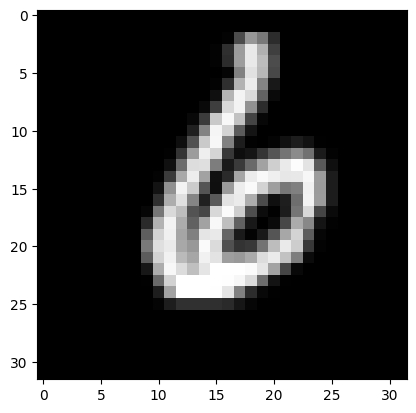

In [68]:
# Now let's do one epoch of model training


labels = F.one_hot(targets, num_classes=10)
outputs = model(samples)
probs = softmax(outputs)
plt.imshow(samples[0].view(32, 32).numpy(), cmap='gray')
print(f"Target: {targets[0].item()}")
for i, prob in enumerate(probs[0]):
    print(f"Class {i}: {prob.detach().numpy().round(4)}")

loss = cross_entropy(probs, labels)
loss.backward()
# Now let's update the model parameters
with torch.no_grad():
    model.fc1.weight -= 0.01 * model.fc1.weight.grad
    model.fc1.bias -= 0.01 * model.fc1.bias.grad


## Surprise, surprise -- PyTorch has also the CrossEntropy Loss implementation, but again, it was good to see that we can define our own custom cost function

In [69]:
cross_entropy = nn.CrossEntropyLoss()
# With one little simplification: Our custom cross entropy function was using the one-hot encoded labels and the
# softmax probabilities. But the built-in cross entropy loss function uses the logits and the targets directly.

# Now Let's do the training for some more epochs, i.e. we are unboxing the model.train() we did last week

In [70]:
model = Model()
data = Data(size=10000)

In [71]:

learning_rate = 0.01
for epoch in range(20):
    correct = 0
    num_samples = 0
    for samples, targets in data.dataloader:
        model.zero_grad()
        samples = samples.view(samples.shape[0], -1)
        outputs = model(samples)
        loss = cross_entropy(outputs, targets)
        loss.backward()
        probs = softmax(outputs)
        correct += (probs.argmax(dim=1) == targets).sum()
        num_samples += samples.shape[0]
        with torch.no_grad():
            model.fc1.weight -= learning_rate * model.fc1.weight.grad
            model.fc1.bias -= learning_rate * model.fc1.bias.grad
    print(f"Epoch {epoch} loss: {loss.item()}, accuracy: {correct / num_samples}")

Epoch 0 loss: 0.21214301884174347, accuracy: 0.864300012588501
Epoch 1 loss: 0.1618378609418869, accuracy: 0.9041000008583069
Epoch 2 loss: 0.13577792048454285, accuracy: 0.9138000011444092
Epoch 3 loss: 0.11814910173416138, accuracy: 0.9196000099182129
Epoch 4 loss: 0.10519250482320786, accuracy: 0.9223999977111816
Epoch 5 loss: 0.09527672827243805, accuracy: 0.9247000217437744
Epoch 6 loss: 0.08746995031833649, accuracy: 0.9266999959945679
Epoch 7 loss: 0.0811779648065567, accuracy: 0.9277999997138977
Epoch 8 loss: 0.07600357383489609, accuracy: 0.9290000200271606
Epoch 9 loss: 0.0716727003455162, accuracy: 0.9302999973297119
Epoch 10 loss: 0.06799287348985672, accuracy: 0.9312000274658203
Epoch 11 loss: 0.0648239478468895, accuracy: 0.9316999912261963
Epoch 12 loss: 0.062062665820121765, accuracy: 0.9326000213623047
Epoch 13 loss: 0.05963168665766716, accuracy: 0.9334999918937683
Epoch 14 loss: 0.057471927255392075, accuracy: 0.9341999888420105
Epoch 15 loss: 0.055537182837724686, a

# Finally, would you be happy if I told you that pytorch has its own SDG optimizer that does the weight update?

In [72]:
# let's define the optimizer
data2 = Data(test=True)
data = Data(size=10000)

model = Model()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
for epoch in range(20):
    correct = 0
    num_samples = 0
    for samples, targets in data2.dataloader:
        samples = samples.view(samples.shape[0], -1)
        outputs = model(samples)
        probs = softmax(outputs)
        correct += (probs.argmax(dim=1) == targets).sum()
        num_samples += samples.shape[0]
    print(f"Epoch {epoch} loss: {loss.item()}, accuracy: {correct / num_samples}")
    for samples, targets in data.dataloader:
        optimizer.zero_grad()
        samples = samples.view(samples.shape[0], -1)
        outputs = model(samples)
        loss = cross_entropy(outputs, targets)
        loss.backward()
        optimizer.step()


Epoch 0 loss: 0.049426428973674774, accuracy: 0.06790000200271606
Epoch 1 loss: 0.24167349934577942, accuracy: 0.8952000141143799
Epoch 2 loss: 0.17874479293823242, accuracy: 0.9009000062942505
Epoch 3 loss: 0.15093809366226196, accuracy: 0.902999997138977
Epoch 4 loss: 0.13451159000396729, accuracy: 0.9047999978065491
Epoch 5 loss: 0.1233634203672409, accuracy: 0.9052000045776367
Epoch 6 loss: 0.115183524787426, accuracy: 0.9057000279426575
Epoch 7 loss: 0.10888759791851044, accuracy: 0.906499981880188
Epoch 8 loss: 0.10388539731502533, accuracy: 0.9068999886512756
Epoch 9 loss: 0.09982085973024368, accuracy: 0.9075000286102295
Epoch 10 loss: 0.09646110981702805, accuracy: 0.90829998254776
Epoch 11 loss: 0.09364518523216248, accuracy: 0.9086999893188477
Epoch 12 loss: 0.09125988185405731, accuracy: 0.9090999960899353
Epoch 13 loss: 0.08921913802623749, accuracy: 0.9090999960899353
Epoch 14 loss: 0.0874590203166008, accuracy: 0.9093000292778015
Epoch 15 loss: 0.08592912554740906, accur